# Hypothesis Testing — Customer Care Calls & Emails
This notebook tests whether email-based and customer-care-call-based features
are statistically significant indicators of churn (`Prospect_Outcome`).

### Approach
1. Load the model-ready dataset (all rows retained, including *Open*).
2. For statistical tests, compare **Won** vs **Churned** only — *Open* is excluded
   from test subsets because its outcome is unknown.
3. Apply **normality checks** to decide between parametric (Welch's t-test) and
   non-parametric (Mann-Whitney U) tests.
4. Use **Chi-Square Test of Independence** for categorical features.
5. Significance level: **α = 0.05** throughout.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# Plotting defaults
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

---
## 1 · Data Loading & Preparation

In [5]:
project_root = Path.cwd().parent.parent
df = pd.read_csv(project_root / "data" / "processed" / "model_ready_dataset.csv", low_memory=False)
print(f"Full dataset shape: {df.shape}")
print(f"\nProspect_Outcome distribution:")
print(df["Prospect_Outcome"].value_counts())

Full dataset shape: (122082, 61)

Prospect_Outcome distribution:
Prospect_Outcome
Won        101226
Churned     12668
Open         8188
Name: count, dtype: int64


In [6]:
# Create binary churn flag — used ONLY for testing subsets
# Open rows are kept in df but excluded from hypothesis tests
df_test = df[df["Prospect_Outcome"].isin(["Won", "Churned"])].copy()
df_test["is_churn"] = (df_test["Prospect_Outcome"] == "Churned").astype(int)

churned = df_test[df_test["is_churn"] == 1]
won     = df_test[df_test["is_churn"] == 0]

print(f"Test subset shape (Won + Churned only): {df_test.shape}")
print(f"  Churned: {len(churned):,}  |  Won: {len(won):,}")

Test subset shape (Won + Churned only): (113894, 62)
  Churned: 12,668  |  Won: 101,226


In [7]:
# Define the email and CC features we will test
em_numeric_features = [
    "em_email_count",
    "em_agent_chase_total",
    "em_agent_chase_max",
    "em_auto_renewal_status_max",
    "em_sentiment_score_mean",
    "em_sentiment_score_max",
    "em_crm_contractor_suggested_leave",
    "em_accreditation_health",
    "em_churn_risk_signals",
    "em_dissatisfaction_index",
    "em_engagement_signals",
]

cc_numeric_features = [
    "cc_call_count",
    "cc_dissatisfaction_index",
    "cc_platform_issues_index",
    "cc_pricing_index",
    "cc_engagement_index",
    "cc_sentiment_score_avg",
]

categorical_features = [
    "em_sentiment_mode",
    "em_membership_level_mode",
    "cc_sentiment_mode",
]

all_numeric = em_numeric_features + cc_numeric_features
print(f"Numeric features to test: {len(all_numeric)}")
print(f"Categorical features to test: {len(categorical_features)}")

Numeric features to test: 17
Categorical features to test: 3


---
## 2 · Normality Checks (Shapiro-Wilk)

We sample 5,000 observations per group (Shapiro-Wilk has a limit and is
sensitive to large samples). If **either** group is non-normal (p < 0.05),
we use the Mann-Whitney U test; otherwise Welch's t-test.

In [8]:
SAMPLE_N = 5000
normality_results = []

for feat in all_numeric:
    for label, subset in [("Churned", churned), ("Won", won)]:
        data = subset[feat].dropna()
        sample = data.sample(n=min(SAMPLE_N, len(data)), random_state=42)
        if sample.nunique() < 2:
            p = 0.0   # constant → not normal
        else:
            _, p = stats.shapiro(sample)
        normality_results.append({
            "Feature": feat, "Group": label,
            "Shapiro_p": round(p, 6),
            "Normal (p>0.05)": p > 0.05
        })

norm_df = pd.DataFrame(normality_results)
print(norm_df.to_string(index=False))

                          Feature   Group  Shapiro_p  Normal (p>0.05)
                   em_email_count Churned        0.0            False
                   em_email_count     Won        0.0            False
             em_agent_chase_total Churned        0.0            False
             em_agent_chase_total     Won        0.0            False
               em_agent_chase_max Churned        0.0            False
               em_agent_chase_max     Won        0.0            False
       em_auto_renewal_status_max Churned        0.0            False
       em_auto_renewal_status_max     Won        0.0            False
          em_sentiment_score_mean Churned        0.0            False
          em_sentiment_score_mean     Won        0.0            False
           em_sentiment_score_max Churned        0.0            False
           em_sentiment_score_max     Won        0.0            False
em_crm_contractor_suggested_leave Churned        0.0            False
em_crm_contractor_su

In [9]:
# Determine test choice per feature
test_choice = {}
for feat in all_numeric:
    sub = norm_df[norm_df["Feature"] == feat]
    both_normal = sub["Normal (p>0.05)"].all()
    test_choice[feat] = "Welch's t-test" if both_normal else "Mann-Whitney U"

print("\nTest selection per feature:")
for f, t in test_choice.items():
    print(f"  {f:45s} → {t}")


Test selection per feature:
  em_email_count                                → Mann-Whitney U
  em_agent_chase_total                          → Mann-Whitney U
  em_agent_chase_max                            → Mann-Whitney U
  em_auto_renewal_status_max                    → Mann-Whitney U
  em_sentiment_score_mean                       → Mann-Whitney U
  em_sentiment_score_max                        → Mann-Whitney U
  em_crm_contractor_suggested_leave             → Mann-Whitney U
  em_accreditation_health                       → Mann-Whitney U
  em_churn_risk_signals                         → Mann-Whitney U
  em_dissatisfaction_index                      → Mann-Whitney U
  em_engagement_signals                         → Mann-Whitney U
  cc_call_count                                 → Mann-Whitney U
  cc_dissatisfaction_index                      → Mann-Whitney U
  cc_platform_issues_index                      → Mann-Whitney U
  cc_pricing_index                              → Mann-Whitne

---
## 3 · Hypothesis 1 — Interaction Volume

> **H₀:** There is no significant difference in the volume of emails / CC calls
> between customers who churn and those who are retained.
>
> **H₁:** Churned customers have a significantly different volume of
> emails / CC calls compared to retained customers.

**Features:** `em_email_count`, `cc_call_count`, `em_agent_chase_total`

In [10]:
h1_features = ["em_email_count", "cc_call_count", "em_agent_chase_total"]

h1_results = []
for feat in h1_features:
    x_c = churned[feat].dropna()
    x_w = won[feat].dropna()
    chosen_test = test_choice[feat]

    if chosen_test == "Mann-Whitney U":
        stat, p = stats.mannwhitneyu(x_c, x_w, alternative="two-sided")
    else:
        stat, p = stats.ttest_ind(x_c, x_w, equal_var=False)

    h1_results.append({
        "Feature": feat,
        "Test": chosen_test,
        "Statistic": round(stat, 4),
        "p-value": f"{p:.2e}",
        "Reject H₀": " Yes" if p < 0.05 else " No",
        "Mean (Churned)": round(x_c.mean(), 4),
        "Mean (Won)": round(x_w.mean(), 4),
    })

h1_df = pd.DataFrame(h1_results)
display(h1_df)

,Feature,Test,Statistic,p-value,Reject H₀,Mean (Churned),Mean (Won)
0,em_email_count,Mann-Whitney U,663594719.0,5.63e-15,Yes,1.0890,1.0109
1,cc_call_count,Mann-Whitney U,617887730.0,8.62e-50,Yes,0.0705,0.1384
2,em_agent_chase_total,Mann-Whitney U,674514817.0,8.02e-32,Yes,1.6032,1.2305


---
## 4 · Hypothesis 2 — Sentiment & Dissatisfaction

> **H₀:** There is no significant difference in sentiment scores and
> dissatisfaction indices between churned and retained customers.
>
> **H₁:** Churned customers exhibit significantly lower sentiment
> and/or higher dissatisfaction compared to retained customers.

**Features:** `em_sentiment_score_mean`, `em_dissatisfaction_index`,
`cc_sentiment_score_avg`, `cc_dissatisfaction_index`

In [11]:
h2_features = [
    "em_sentiment_score_mean", "em_dissatisfaction_index",
    "cc_sentiment_score_avg", "cc_dissatisfaction_index",
]

h2_results = []
for feat in h2_features:
    x_c = churned[feat].dropna()
    x_w = won[feat].dropna()
    chosen_test = test_choice[feat]

    if chosen_test == "Mann-Whitney U":
        stat, p = stats.mannwhitneyu(x_c, x_w, alternative="two-sided")
    else:
        stat, p = stats.ttest_ind(x_c, x_w, equal_var=False)

    h2_results.append({
        "Feature": feat,
        "Test": chosen_test,
        "Statistic": round(stat, 4),
        "p-value": f"{p:.2e}",
        "Reject H₀": "Yes" if p < 0.05 else "No",
        "Mean (Churned)": round(x_c.mean(), 4),
        "Mean (Won)": round(x_w.mean(), 4),
    })

h2_df = pd.DataFrame(h2_results)
display(h2_df)

,Feature,Test,Statistic,p-value,Reject H₀,Mean (Churned),Mean (Won)
0,em_sentiment_score_mean,Mann-Whitney U,646672543.0,5.42e-02,No,16.7183,16.4537
1,em_dissatisfaction_index,Mann-Whitney U,697004462.5,1.72e-150,Yes,0.0465,0.0243
2,cc_sentiment_score_avg,Mann-Whitney U,617619922.0,6.95e-51,Yes,2.9365,5.7871
3,cc_dissatisfaction_index,Mann-Whitney U,639020527.0,1.04e-02,Yes,0.0038,0.0036


---
## 5 · Hypothesis 3 — Risk Signals & Specific Issues

> **H₀:** The presence of churn risk signals (contractor suggesting leave,
> competitor mentions, platform issues, pricing concerns) does not differ
> significantly between churned and retained customers.
>
> **H₁:** Churned customers exhibit significantly higher levels of
> churn risk signals and issue indicators.

**Features:** `em_churn_risk_signals`, `em_crm_contractor_suggested_leave`,
`cc_platform_issues_index`, `cc_pricing_index`

In [12]:
h3_features = [
    "em_churn_risk_signals", "em_crm_contractor_suggested_leave",
    "cc_platform_issues_index", "cc_pricing_index",
]

h3_results = []
for feat in h3_features:
    x_c = churned[feat].dropna()
    x_w = won[feat].dropna()
    chosen_test = test_choice[feat]

    if chosen_test == "Mann-Whitney U":
        stat, p = stats.mannwhitneyu(x_c, x_w, alternative="two-sided")
    else:
        stat, p = stats.ttest_ind(x_c, x_w, equal_var=False)

    h3_results.append({
        "Feature": feat,
        "Test": chosen_test,
        "Statistic": round(stat, 4),
        "p-value": f"{p:.2e}",
        "Reject H₀": "Yes" if p < 0.05 else " No",
        "Mean (Churned)": round(x_c.mean(), 4),
        "Mean (Won)": round(x_w.mean(), 4),
    })

h3_df = pd.DataFrame(h3_results)
display(h3_df)

,Feature,Test,Statistic,p-value,Reject H₀,Mean (Churned),Mean (Won)
0,em_churn_risk_signals,Mann-Whitney U,748845800.5,0.00e+00,Yes,0.0479,0.0113
1,em_crm_contractor_suggested_leave,Mann-Whitney U,754294232.5,0.00e+00,Yes,0.1113,0.0145
2,cc_platform_issues_index,Mann-Whitney U,631873250.5,5.24e-25,Yes,0.0026,0.0063
3,cc_pricing_index,Mann-Whitney U,637489479.0,1.24e-07,Yes,0.0034,0.0040


---
## 6 · Hypothesis 4 — Engagement & Accreditation Health

> **H₀:** Engagement signals and accreditation health do not differ
> significantly between churned and retained customers.
>
> **H₁:** Retained customers have significantly higher engagement
> and accreditation health scores.

**Features:** `em_engagement_signals`, `cc_engagement_index`,
`em_accreditation_health`

In [13]:
h4_features = [
    "em_engagement_signals", "cc_engagement_index", "em_accreditation_health",
]

h4_results = []
for feat in h4_features:
    x_c = churned[feat].dropna()
    x_w = won[feat].dropna()
    chosen_test = test_choice[feat]

    if chosen_test == "Mann-Whitney U":
        stat, p = stats.mannwhitneyu(x_c, x_w, alternative="two-sided")
    else:
        stat, p = stats.ttest_ind(x_c, x_w, equal_var=False)

    h4_results.append({
        "Feature": feat,
        "Test": chosen_test,
        "Statistic": round(stat, 4),
        "p-value": f"{p:.2e}",
        "Reject H₀": "Yes" if p < 0.05 else " No",
        "Mean (Churned)": round(x_c.mean(), 4),
        "Mean (Won)": round(x_w.mean(), 4),
    })

h4_df = pd.DataFrame(h4_results)
display(h4_df)

,Feature,Test,Statistic,p-value,Reject H₀,Mean (Churned),Mean (Won)
0,em_engagement_signals,Mann-Whitney U,665026271.5,7.60e-17,Yes,0.1018,0.0910
1,cc_engagement_index,Mann-Whitney U,621976659.5,5.57e-49,Yes,0.0047,0.0115
2,em_accreditation_health,Mann-Whitney U,647890029.5,1.88e-02,Yes,0.1143,0.1272


---
## 7 · Hypothesis 5 — Categorical Feature Association (Chi-Square)

> **H₀:** The distribution of categorical sentiment / membership modes
> is independent of churn status.
>
> **H₁:** The distribution of these categorical features is significantly
> associated with churn status.

**Features:** `em_sentiment_mode`, `cc_sentiment_mode`, `em_membership_level_mode`

In [14]:
h5_results = []
for feat in categorical_features:
    ct = pd.crosstab(df_test[feat], df_test["is_churn"])
    chi2, p, dof, expected = stats.chi2_contingency(ct)

    h5_results.append({
        "Feature": feat,
        "Test": "Chi-Square",
        "Statistic (χ²)": round(chi2, 4),
        "dof": dof,
        "p-value": f"{p:.2e}",
        "Reject H₀": " Yes" if p < 0.05 else "No",
    })

h5_df = pd.DataFrame(h5_results)
display(h5_df)

,Feature,Test,Statistic (χ²),dof,p-value,Reject H₀
0,em_sentiment_mode,Chi-Square,1360.9041,4,2.07e-293,Yes
1,em_membership_level_mode,Chi-Square,203.3061,9,6.71e-39,Yes
2,cc_sentiment_mode,Chi-Square,251.3072,4,3.40e-53,Yes


In [18]:
# Show crosstab proportions for each categorical feature
for feat in categorical_features:
    ct = pd.crosstab(df_test[feat], df_test["Prospect_Outcome"], normalize="index")
    print(f"\n--- {feat} ---")
    display(ct.apply(lambda col: col.map(lambda x: f"{x:.2%}")))



--- em_sentiment_mode ---


Prospect_Outcome,Churned,Won
em_sentiment_mode,,
Dissatisfied,30.59%,69.41%
Neutral,9.43%,90.57%
No Interaction,10.51%,89.49%
Not Discussed,14.39%,85.61%
Satisfied,2.72%,97.28%



--- em_membership_level_mode ---


Prospect_Outcome,Churned,Won
em_membership_level_mode,,
Accredited,11.17%,88.83%
Bronze,100.00%,0.00%
Express,0.00%,100.00%
Gold,0.00%,100.00%
In Progress,12.27%,87.73%
Members Only,17.14%,82.86%
No Interaction,10.51%,89.49%
Not Accredited,7.69%,92.31%
Not Discussed,15.56%,84.44%



--- cc_sentiment_mode ---


Prospect_Outcome,Churned,Won
cc_sentiment_mode,,
Dissatisfied,12.90%,87.10%
Neutral,7.39%,92.61%
No Interaction,11.51%,88.49%
Not Discussed,8.87%,91.13%
Satisfied,4.38%,95.62%


---
## 8 · Consolidated Results Summary

In [19]:
# Merge all results into one consolidated table
all_results = pd.concat([
    h1_df.assign(Hypothesis="H1: Interaction Volume"),
    h2_df.assign(Hypothesis="H2: Sentiment & Dissatisfaction"),
    h3_df.assign(Hypothesis="H3: Risk Signals & Issues"),
    h4_df.assign(Hypothesis="H4: Engagement & Health"),
], ignore_index=True)

# Add chi-square results (slightly different columns)
chi_sq_for_merge = h5_df.rename(columns={"Statistic (χ²)": "Statistic"}).copy()
chi_sq_for_merge["Hypothesis"] = "H5: Categorical Modes"
chi_sq_for_merge["Mean (Churned)"] = "—"
chi_sq_for_merge["Mean (Won)"] = "—"

summary_df = pd.concat([all_results, chi_sq_for_merge], ignore_index=True)

# Reorder columns
col_order = ["Hypothesis", "Feature", "Test", "Statistic", "p-value",
             "Reject H₀", "Mean (Churned)", "Mean (Won)"]
summary_df = summary_df[[c for c in col_order if c in summary_df.columns]]

print("=" * 100)
print("CONSOLIDATED HYPOTHESIS TEST RESULTS (α = 0.05)")
print("=" * 100)
display(summary_df)

CONSOLIDATED HYPOTHESIS TEST RESULTS (α = 0.05)


,Hypothesis,Feature,Test,Statistic,p-value,Reject H₀,Mean (Churned),Mean (Won)
0,H1: Interaction Volume,em_email_count,Mann-Whitney U,6.635947e+08,5.63e-15,Yes,1.089,1.0109
1,H1: Interaction Volume,cc_call_count,Mann-Whitney U,6.178877e+08,8.62e-50,Yes,0.0705,0.1384
2,H1: Interaction Volume,em_agent_chase_total,Mann-Whitney U,6.745148e+08,8.02e-32,Yes,1.6032,1.2305
3,H2: Sentiment & Dissatisfaction,em_sentiment_score_mean,Mann-Whitney U,6.466725e+08,5.42e-02,No,16.7183,16.4537
4,H2: Sentiment & Dissatisfaction,em_dissatisfaction_index,Mann-Whitney U,6.970045e+08,1.72e-150,Yes,0.0465,0.0243
5,H2: Sentiment & Dissatisfaction,cc_sentiment_score_avg,Mann-Whitney U,6.176199e+08,6.95e-51,Yes,2.9365,5.7871
6,H2: Sentiment & Dissatisfaction,cc_dissatisfaction_index,Mann-Whitney U,6.390205e+08,1.04e-02,Yes,0.0038,0.0036
7,H3: Risk Signals & Issues,em_churn_risk_signals,Mann-Whitney U,7.488458e+08,0.00e+00,Yes,0.0479,0.0113
8,H3: Risk Signals & Issues,em_crm_contractor_suggested_leave,Mann-Whitney U,7.542942e+08,0.00e+00,Yes,0.1113,0.0145
9,H3: Risk Signals & Issues,cc_platform_issues_index,Mann-Whitney U,6.318733e+08,5.24e-25,Yes,0.0026,0.0063


---
## 9 · Visualisations

### 9.1 — Box Plots: Numeric Email Features by Churn Status

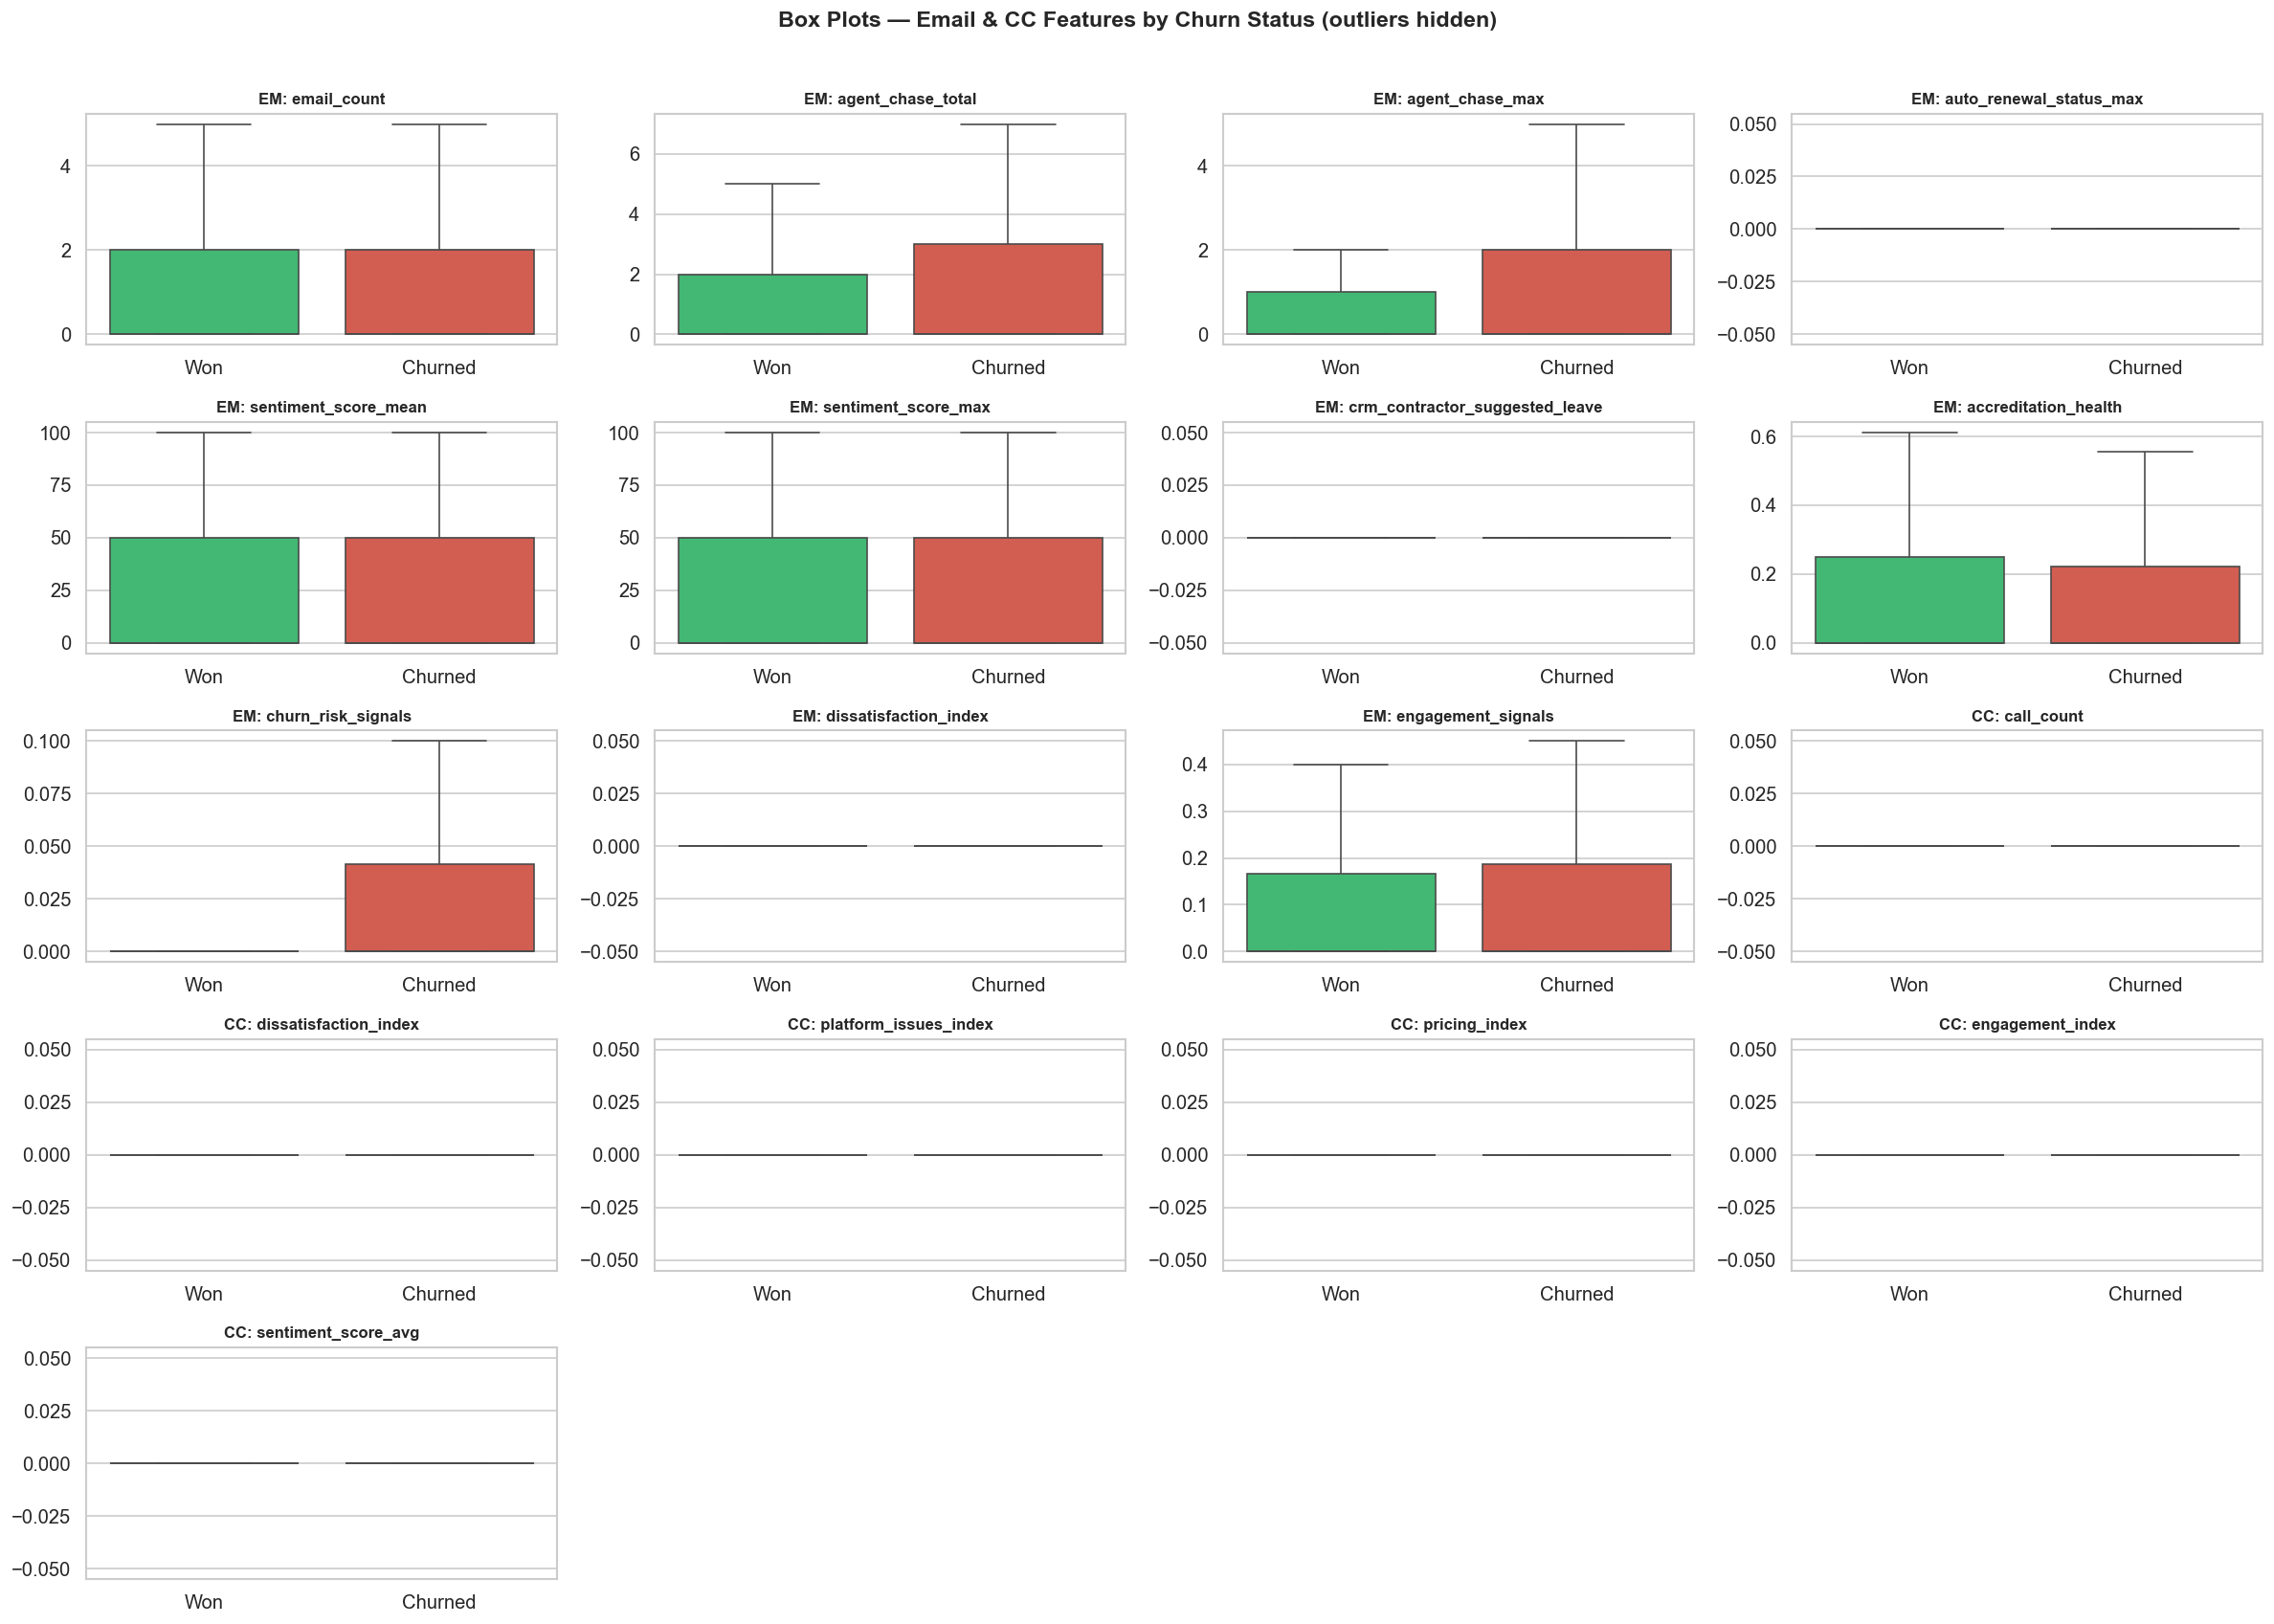

In [23]:
fig, axes = plt.subplots(5, 4, figsize=(20, 14))
axes = axes.flatten()

for i, feat in enumerate(all_numeric):
    ax = axes[i]
    sns.boxplot(data=df_test, x="Prospect_Outcome", y=feat, ax=ax,
                palette={"Churned": "#e74c3c", "Won": "#2ecc71"},
                showfliers=False)
    ax.set_title(feat.replace("em_", "EM: ").replace("cc_", "CC: "),
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")

# Hide unused subplots
for j in range(len(all_numeric), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Box Plots — Email & CC Features by Churn Status (outliers hidden)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 9.2 — Mean Comparison Bar Charts

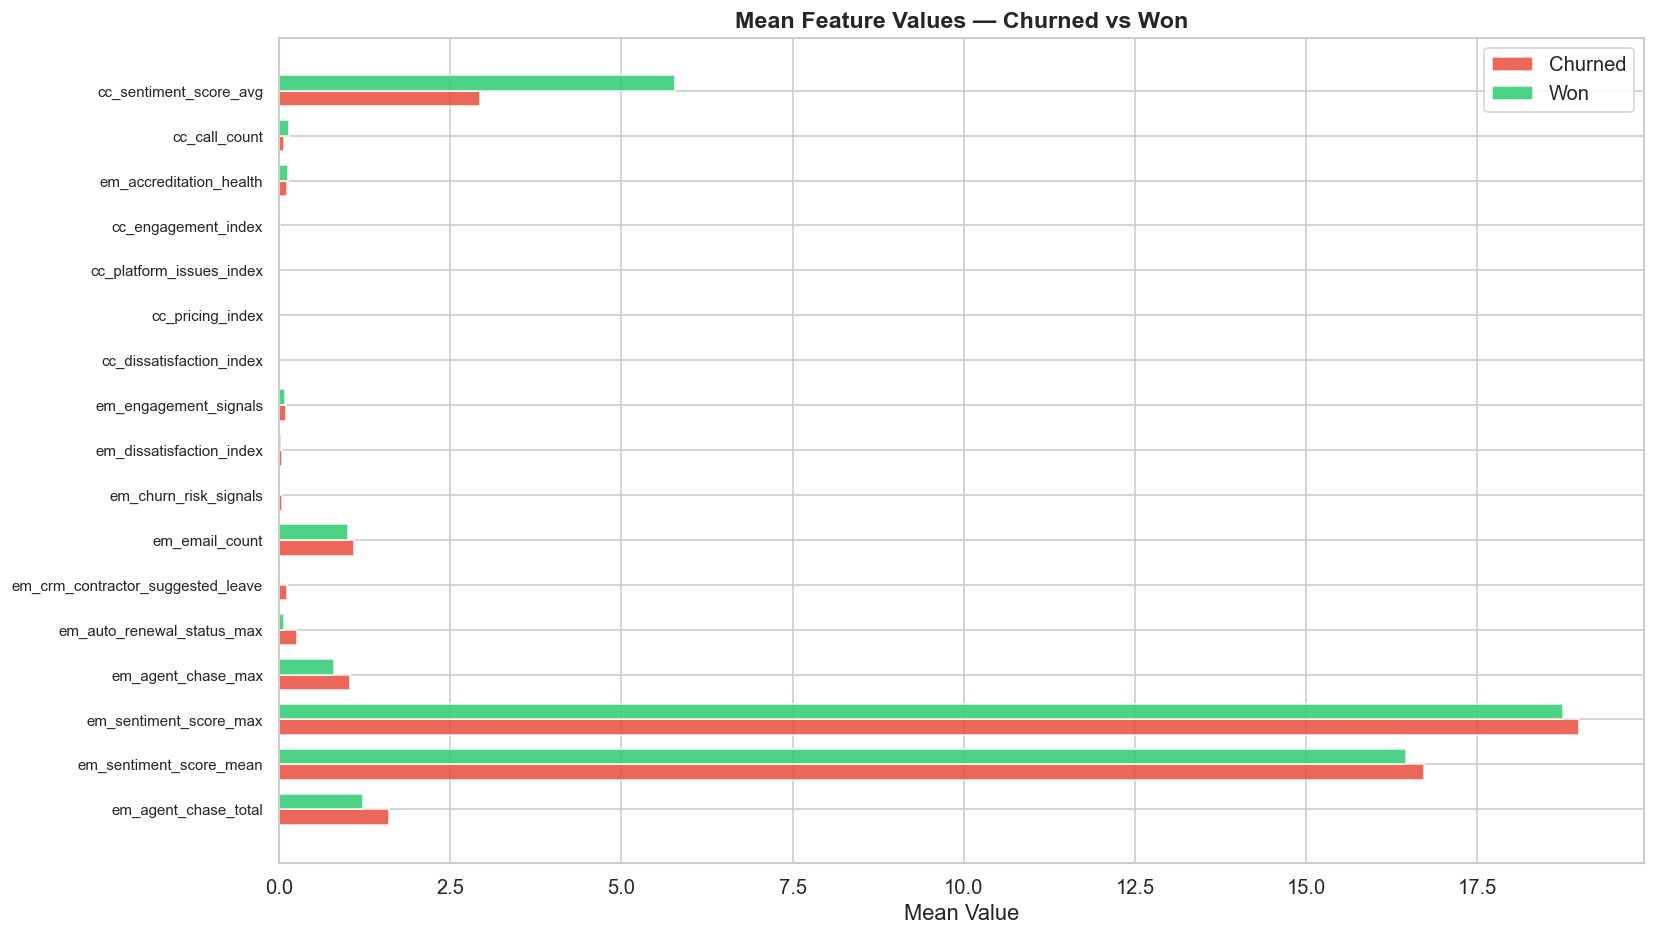

In [21]:
means = df_test.groupby("Prospect_Outcome")[all_numeric].mean().T
means["Diff"] = means["Churned"] - means["Won"]
means = means.sort_values("Diff", ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
x = range(len(means))
width = 0.35

ax.barh([i - width/2 for i in x], means["Churned"], height=width,
        label="Churned", color="#e74c3c", alpha=0.85)
ax.barh([i + width/2 for i in x], means["Won"], height=width,
        label="Won", color="#2ecc71", alpha=0.85)

ax.set_yticks(list(x))
ax.set_yticklabels(means.index, fontsize=9)
ax.set_xlabel("Mean Value")
ax.set_title("Mean Feature Values — Churned vs Won", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

### 9.3 — Categorical Distribution by Churn Status

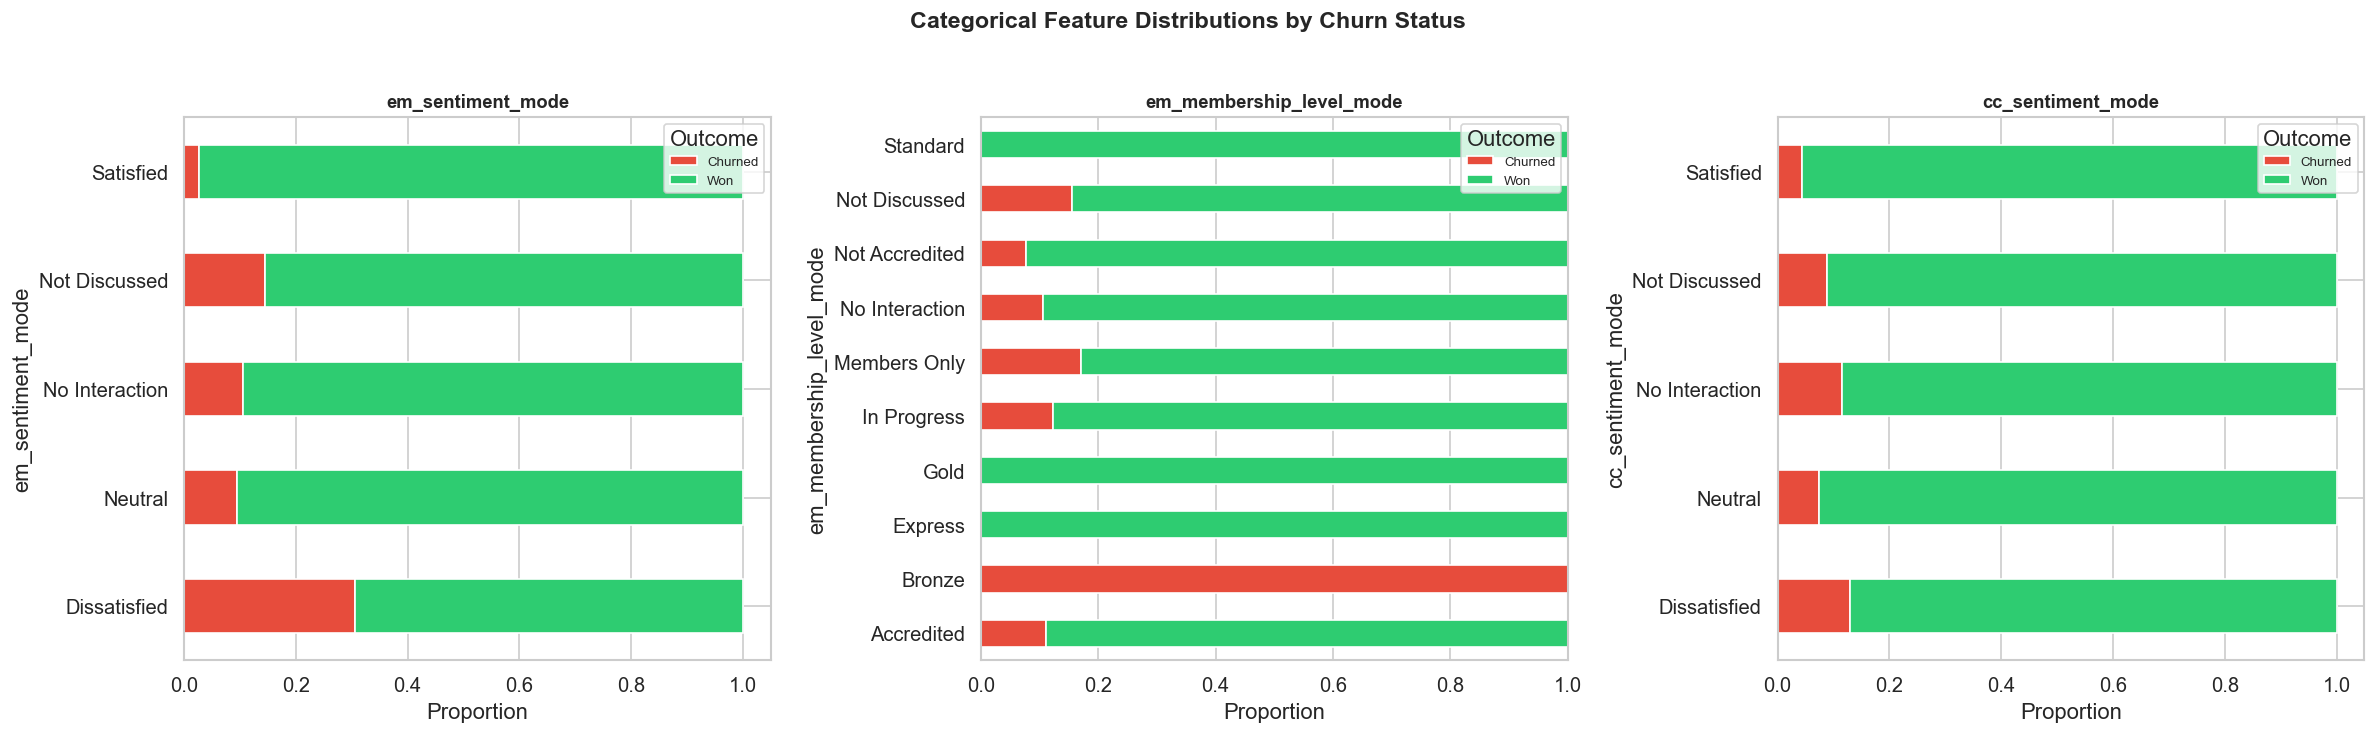

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, feat in enumerate(categorical_features):
    ct = pd.crosstab(df_test[feat], df_test["Prospect_Outcome"])
    ct_pct = ct.div(ct.sum(axis=1), axis=0)
    ct_pct.plot(kind="barh", stacked=True, ax=axes[i],
                color={"Churned": "#e74c3c", "Won": "#2ecc71"})
    axes[i].set_title(feat, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Proportion")
    axes[i].legend(title="Outcome", fontsize=8)

fig.suptitle("Categorical Feature Distributions by Churn Status",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 9.4 — Correlation Heatmap (Email & CC Features with Churn)

In [ ]:
corr_cols = all_numeric + ["is_churn"]
corr_matrix = df_test[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={"size": 8})
ax.set_title("Correlation Heatmap — Email & CC Features + Churn Flag",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 10 · Conclusions

### Key Findings
Based on the hypothesis tests above:

1. **Significant features** (p < 0.05, i.e. we reject H₀) provide statistical
   evidence that their distributions differ between Churned and Won customers.
   These features are strong candidates for inclusion in the predictive model.

2. **Non-significant features** (p ≥ 0.05, i.e. we fail to reject H₀) do not
   show a statistically significant difference. However, this does not mean they
   are useless — they may still contribute in combination with other features
   inside a machine learning model.

### Next Steps
- Feed the summary results to the team for feature selection decisions.
- Proceed to model building with features confirmed as significant.